<a href="https://colab.research.google.com/github/JustmeLu/Tareas-automatizacionInicial/blob/main/2-Ejercicios/07-Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/andres-merino/AprendizajeAutomaticoInicial-05-N0105/blob/main/2-Ejercicios/07-Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i.imgur.com/nt7hloA.png" width="100">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#0030A1" size="7">|</font><br>
            <font color="#0030A1" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="5">
                <b>Facultad de Ciencias Exactas, Naturales y Ambientales</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="4">
                Aprendizaje Automático Inicial &bull; Perceptrón
            </font></p>
            <p style="font-style: oblique;"><font color="#0030A1" size="3">
              Luisa Guerrero &bull; 2026-01
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='264CC7'> Introducción </font>

A lo largo de este taller, aplicaremos un perceptrón para clasificar un conjunto de datos.

Los paquetes necesarios son:

In [11]:
# Paquetes necesarios
from sklearn.datasets import fetch_openml
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.utils import to_categorical
import random
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report





---
## <font color='264CC7'> Clasificación </font>

Se usará el conjunto de datos de dígitos de MNIST.

In [2]:
# Cargamos el dataset MNIST
X, y = fetch_openml('mnist_784', return_X_y=True, parser='auto')


### <font color='264CC7'> Preprocesamiento de datos </font>

Primero necesitas el conjunto de datos. Los datos a utilzar son los seleccionados en la clase anterior.

<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Carga el conjunto de datos y procésalos:
<ul>
  <li>Muestra algunos datos.</li>
  <li>Muestra una descripción de los datos.</li>
  <li>Escala los datos si es necesario.</li>
</ul>
</div>

In [3]:

# Leer los datos

X, y = fetch_openml('mnist_784', return_X_y=True, parser='auto')

# Convertir tipos
X = X.astype(float)
y = y.astype(int)

In [4]:

# Muestro los primeros registros
data = pd.DataFrame(X)
data['label'] = y
display(data.head())

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9


In [5]:

# Descripción de los datos
data.describe()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,label
count,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.0,70000.0,70000.0,70000.0,70000.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.099543,0.046629,0.016614,0.012957,0.001714,0.0,0.0,0.0,0.0,4.452429
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.256304,2.783732,1.561822,1.553796,0.320889,0.0,0.0,0.0,0.0,2.890195
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,2.000000
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,4.000000
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,7.000000
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,253.000000,253.000000,254.000000,62.000000,0.0,0.0,0.0,0.0,9.000000


In [6]:

# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.iloc[:, :-1])


### <font color='264CC7'> Determinación de la red </font>

<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Determina una red neuronal para clasificar los datos:
<ul>
  <li>Define la red.</li>
  <li>Compila la red.</li>
  <li>Presenta un resumen de la red.</li>
</ul>
</div>


In [9]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.config.experimental.enable_op_determinism()
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
    os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [13]:

# Codificar las clases
y_one_hot = to_categorical(y)


# Definir la red neuronal
set_seed(42)
model = Sequential([
    Input(shape=(784,)),
    Dense(60, activation='tanh'),
    Dense(28, activation='tanh'),
    Dense(10, activation='softmax')
])


# Compilar la red
optimizer = SGD(learning_rate=0.1)
loss = CategoricalCrossentropy()

model.compile(
    optimizer=optimizer,
    loss=loss
)


# Resumen del modelo
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 60)             │        47,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 28)             │         1,708 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,098 (191.79 KB)

 Trainable params: 49,098 (191.79 KB)

 Non-trainable params: 0 (0.00 B)

La red neuronal está compuesta por dos capas ocultas con funciones de activación tangente hiperbólica y una capa de salida con función softmax.


### <font color='264CC7'> Entrenamiento del modelo y evaluación </font>


<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Entrena el modelo y evalúalo:
<ul>
  <li>Entrena el modelo.</li>
  <li>Evalúa el modelo con el conjunto de datos de prueba.</li>
  <li>Genera una matriz de confusión y muestra las métricas de evaluación.</li>
</ul>
</div>

Epoch 1/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4299
Epoch 2/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1698
Epoch 3/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1215
Epoch 4/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0910
Epoch 5/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0725
Epoch 6/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0583
Epoch 7/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0458
Epoch 8/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0383
Epoch 9/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0335
Epoch 10/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0269
Epoch 11/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0221
Epoch 12/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0194
Epoch 13/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0189
Epoch 14/20
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0152
Epoch 15/20
1750/1750 ━━━━━━━

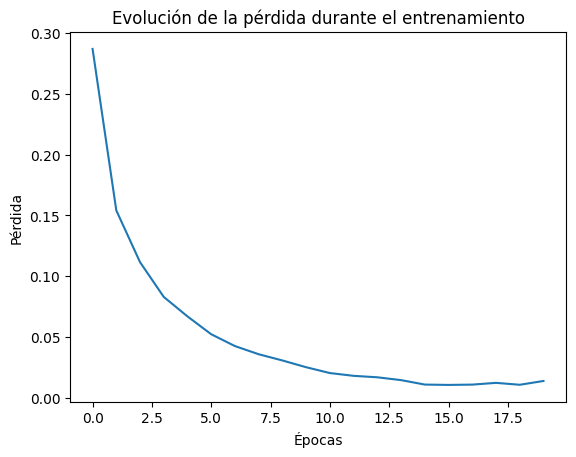

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Precisión del modelo: 0.95
Matriz de confusión:
[[1351    1    2    0    2    6   11    0    5    3]
 [   0 1539    8    8    0    5    3    6    4    2]
 [   8    4 1330   16    4    4    6    8   15    3]
 [   5    2   20 1346    1   28    0   10   13    3]
 [   1    6    6    3 1274    2    9    8    5   51]
 [   8    2    6   26    4 1179   10    4   14   10]
 [   8    1    4    0    8   11 1339    0    3    1]
 [   1    5   12    8    9    1    0 1403    3   17]
 [   6    4    5   19    3   18    6   10 1285    9]
 [   2    7    2   17   22    5    1   29    7 1299]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.95      0.95      0.95      1398
           3       0.93      0.94      0.94      1428
           4       0.96      0.93      0.95      1365
           5       0.94      

In [14]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_one_hot,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Entrenar el modelo
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    verbose=1
)

# Visualizar la pérdida
plt.plot(history.history['loss'])
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.show()

# Evaluación del modelo
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# Precisión del modelo
accuracy = round(accuracy_score(y_test_labels, y_pred), 2)
print("Precisión del modelo:", accuracy)

# Matriz de confusión
cm = confusion_matrix(y_test_labels, y_pred)
print("Matriz de confusión:")
print(cm)

# Reporte de clasificación
print("Reporte de clasificación:")
print(classification_report(y_test_labels, y_pred))

El modelo logró una precisión del 95 %, lo cual es un resultado bastante bueno ya que se trata de una red densa

Al observar la curva de pérdida durante el entrenamiento se nota que esta disminuye de forma rápida en las primeras épocas y luego se estabiliza lo que indica que el modelo aprende correctamente y que entrenarlo durante 20 épocas es suficiente.